In [5]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
import pandas as pd

In [7]:
df=pd.read_csv(r"C:\Users\USER\Desktop\2026\Own_projects\ML_Projects\predictEmployeeChurn\employee_data.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0.0,sales,low
1,0.80,0.86,5,262,6,0,1,0.0,sales,medium
2,0.11,0.88,7,272,4,0,1,0.0,sales,medium
3,0.72,0.87,5,223,5,0,1,0.0,sales,low
4,0.37,0.52,2,159,3,0,1,0.0,sales,low


In [9]:
df.shape

(11582, 10)

In [13]:
df['department'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD', nan], dtype=object)

In [31]:
import pandas as pd

def high_salary_per_department(df):
    result = df.groupby('department')['salary'].apply(lambda x: (x == 'high').sum())
    return result


In [33]:
print(high_salary_per_department(df))

department
IT              68
RandD           44
accounting      61
hr              38
management      68
marketing       55
product_mng     49
sales          230
support        124
technical      164
Name: salary, dtype: int64


In [37]:
high_counts=high_salary_per_department(df)

<Figure size 640x480 with 0 Axes>

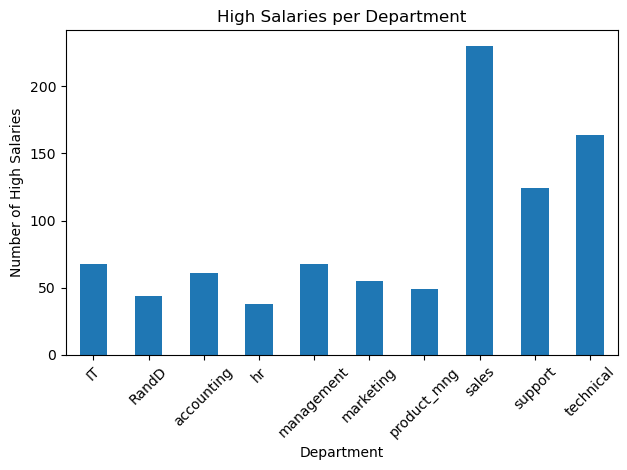

In [39]:
plt.figure()
high_counts.plot(kind='bar')

plt.title('High Salaries per Department')
plt.xlabel('Department')
plt.ylabel('Number of High Salaries')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [53]:
df['satisfaction_level'].unique()

array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])

In [63]:
def satisfy_department(df):
    result=df.groupby('department')['satisfaction_level'].apply(lambda x :(x>=0.65).sum())
    return result

In [65]:
print(satisfy_department(df))

department
IT              504
RandD           360
accounting      298
hr              295
management      193
marketing       329
product_mng     323
sales          1601
support         954
technical      1158
Name: satisfaction_level, dtype: int64


In [67]:
best_employee=satisfy_department(df)

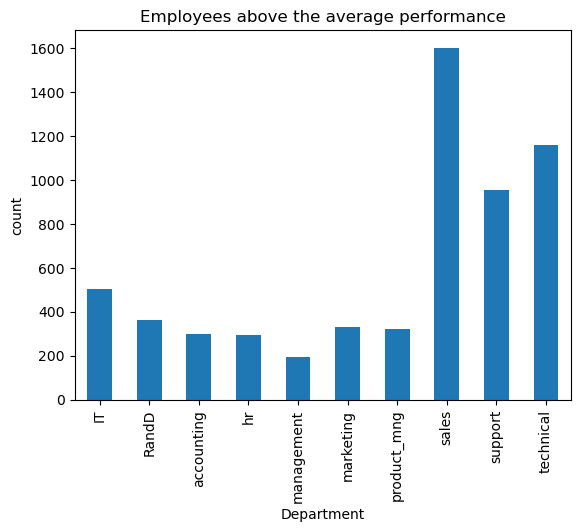

In [71]:
plt.figure()
best_employee.plot(kind='bar')

plt.title('Employees above the average performance')
plt.xlabel('Department')
plt.ylabel('count')

plt.show()

In [73]:
def unsatisfyEmp(df):
    result=df.groupby('department')['satisfaction_level'].apply(lambda x :(x<=0.35).sum())
    return result

In [75]:
print(unsatisfyEmp(df))

department
IT             120
RandD          102
accounting      99
hr              81
management      45
marketing       76
product_mng     81
sales          414
support        230
technical      308
Name: satisfaction_level, dtype: int64


In [81]:
lowest_performance=unsatisfyEmp(df)


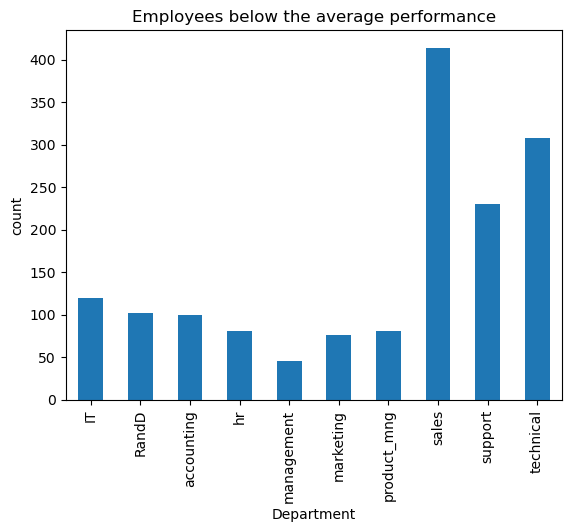

In [87]:
plt.figure()
lowest_performance.plot(kind='bar')

plt.title('Employees below the average performance')
plt.xlabel('Department')
plt.ylabel('count')

plt.show()

In [103]:
def most_quit(df):
    res=df.groupby('department')['quit'].apply(lambda x : (x==1).sum())
    return res

In [105]:
print(most_quit(df))

department
IT             159
RandD           86
accounting     110
hr             113
management      52
marketing      112
product_mng    110
sales          556
support        312
technical      390
Name: quit, dtype: int64


In [107]:
most_quit=most_quit(df)

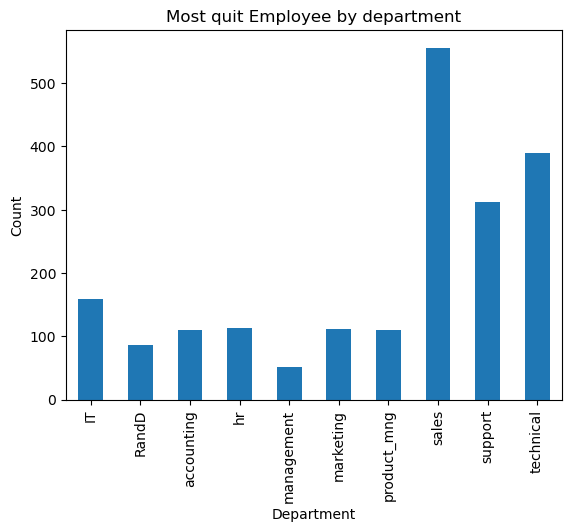

In [109]:
plt.figure()
most_quit.plot(kind='bar')

plt.title("Most quit Employee by department")
plt.xlabel("Department")
plt.ylabel("Count")

plt.show()

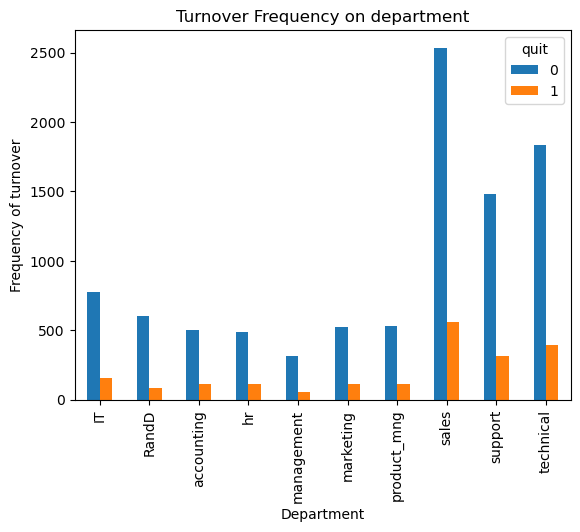

In [113]:
pd.crosstab(df.department,df.quit).plot(kind='bar')
plt.title("Turnover Frequency on department")
plt.xlabel('Department')
plt.ylabel('Frequency of turnover')
plt.show()

In [117]:
cat_vars=['department','salary']
for i in cat_vars:
    cat_list=pd.get_dummies(df[i], prefix=i)
    df=df.join(cat_list)

In [119]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department,salary,...,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0.0,sales,low,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0.0,sales,medium,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0.0,sales,medium,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0.0,sales,low,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0.0,sales,low,...,False,False,False,False,True,False,False,False,True,False


In [123]:
df.drop(columns=['department','salary'],axis=1,inplace=True)

In [125]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department_IT,department_RandD,...,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0.0,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0.0,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0.0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0.0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0.0,False,False,...,False,False,False,False,True,False,False,False,True,False


In [127]:
binary_cols = [
    'department_IT', 'department_RandD', 'department_hr',
    'department_management', 'department_marketing',
    'department_product_mng', 'department_sales',
    'department_support', 'department_technical',
    'salary_high', 'salary_low', 'salary_medium'
]

df[binary_cols] = df[binary_cols].astype(int)

In [129]:
df.loc[:, binary_cols] = df[binary_cols].astype(int)

In [131]:
df[binary_cols] = (df[binary_cols] > 0).astype(int)

In [133]:
print(df[binary_cols].head())

   department_IT  department_RandD  department_hr  department_management  \
0              0                 0              0                      0   
1              0                 0              0                      0   
2              0                 0              0                      0   
3              0                 0              0                      0   
4              0                 0              0                      0   

   department_marketing  department_product_mng  department_sales  \
0                     0                       0                 1   
1                     0                       0                 1   
2                     0                       0                 1   
3                     0                       0                 1   
4                     0                       0                 1   

   department_support  department_technical  salary_high  salary_low  \
0                   0                     0            0

In [137]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,quit,promotion_last_5years,department_IT,department_RandD,...,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0.0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0.0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0.0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0.0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0.0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [145]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df.drop('quit', axis=1).values
y = df['quit'].values

In [151]:
X.shape

(11582, 20)

In [153]:
y.shape

(11582,)

In [157]:
scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)

In [159]:
X_lstm = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y, test_size=0.2, random_state=42
)

In [163]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model=Sequential()

model.add(LSTM(64,input_shape=(1,X.shape[1]),return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [165]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [167]:
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8117 - loss: 0.5047 - val_accuracy: 0.8356 - val_loss: 0.3964
Epoch 2/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8403 - loss: 0.3579 - val_accuracy: 0.8248 - val_loss: 0.3676
Epoch 3/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8434 - loss: 0.3286 - val_accuracy: 0.8735 - val_loss: 0.2865
Epoch 4/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8983 - loss: 0.2565 - val_accuracy: 0.9258 - val_loss: 0.2136
Epoch 5/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9341 - loss: 0.1848 - val_accuracy: 0.9331 - val_loss: 0.1851
Epoch 6/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9454 - loss: 0.1639 - val_accuracy: 0.9409 - val_loss: 0.1768
Epoch 7/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9490 - loss: 0.1657 - val_accuracy: 0.9469 - val_loss: 0.1717
Epoch 8/20
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9514 - loss: 0.1524 - val_accuracy: 0.

In [169]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9467 - loss: 0.1693
Test Accuracy: 0.9503668546676636


In [171]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [173]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 0.03132953718600568
Test MSE: 0.041474927096917975


In [185]:
y_pred_prob = model.predict(X_test)

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [187]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.9656506696880184


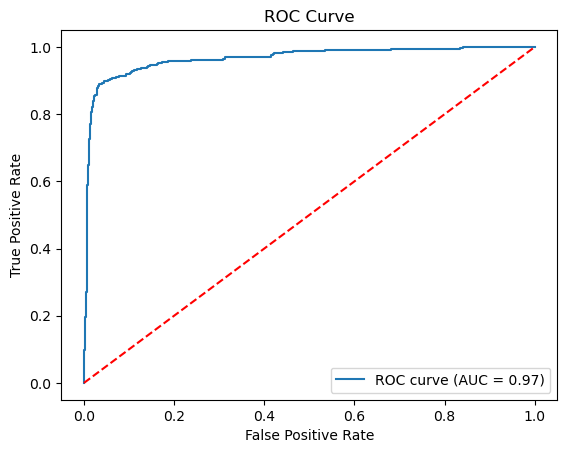

In [189]:
plt.figure()

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')  # random baseline

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.show()